In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

COLOR_MAIN    = '#8B2500'
COLOR_DARK    = '#1A1A1A'
COLOR_NEUTRAL = '#D9D9D9'
COLOR_BG      = '#F7F3ED'
COLOR_ACCENT  = '#C0392B'

PALETTE = [COLOR_MAIN, COLOR_DARK, COLOR_NEUTRAL, COLOR_ACCENT, '#6B1E00', '#4A4A4A']

mpl.rcParams.update({
    'font.family'         : 'Malgun Gothic',
    'axes.unicode_minus'  : False,
    'font.size'           : 11,
    'axes.titlesize'      : 14,
    'axes.labelsize'      : 11,
    'xtick.labelsize'     : 10,
    'ytick.labelsize'     : 10,
    'legend.fontsize'     : 10,
    'figure.facecolor'    : '#F7F3ED',
    'axes.facecolor'      : '#F7F3ED',
    'savefig.facecolor'   : '#F7F3ED',
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.edgecolor'      : '#AAAAAA',
    'axes.linewidth'      : 0.8,
    'axes.grid'           : True,
    'grid.color'          : '#DDDDDD',
    'grid.linewidth'      : 0.5,
    'grid.linestyle'      : '--',
    'figure.dpi'          : 150,
    'savefig.dpi'         : 150,
    'lines.linewidth'     : 2.0,
    'patch.linewidth'     : 0.5,
    'axes.axisbelow'      : True,
})

sns.set_theme(
    style='white',
    palette=PALETTE,
    rc={
        'axes.facecolor': '#F7F3ED', 
        'figure.facecolor': '#F7F3ED',
    }
)

In [3]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

# 1. 기본 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings(action='ignore')

EUR_SCALE = 590

# 2. Transactions 로드 (필요한 컬럼만)
# 처음부터 transactions라는 이름으로 통일해서 읽어옵니다.
transactions = pd.read_csv(
    'transactions_train.csv', 
    parse_dates=['t_dat'],
    dtype={'article_id': str},
    usecols=['t_dat', 'customer_id', 'article_id', 'price']
)

# 3. 가격 변환 및 이상치(Price) 처리
transactions['price_eur'] = (transactions['price'] * EUR_SCALE).round(2)
p99_price = transactions['price_eur'].quantile(0.99)
transactions['price_eur'] = np.clip(transactions['price_eur'], a_min=0.1, a_max=p99_price)

# 4. 이상치 유저 제거 (구매 횟수 상위 0.1%)
user_counts = transactions['customer_id'].value_counts()
threshold = user_counts.quantile(0.999)
valid_user_ids = user_counts[user_counts <= threshold].index

# 필터링 적용
transactions = transactions[transactions['customer_id'].isin(valid_user_ids)].copy()

# 5. Articles & Customers 로드
articles = pd.read_csv('articles.csv', dtype={'article_id': str})
customers = pd.read_csv('customers.csv')

# Customers 전처리
customers = customers.dropna(subset=['age']).copy()
customers = customers[customers['age'].between(15, 100)].copy()
customers['age'] = customers['age'].astype('int8')
cols_to_drop = ['FN', 'Active', 'club_member_status', 'postal_code', 'fashion_news_frequency']
customers.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 6. 최종 병합 (딱 한 번만 실행) transactions + articles
art_cols = ['article_id', 'product_group_name', 'product_type_name', 'colour_group_name']
df = transactions.merge(articles[art_cols], on='article_id', how='left')

print(f"최종 결과 - transactions: {len(transactions):,}행, df(merged): {len(df):,}행")

최종 결과 - transactions: 31,097,423행, df(merged): 31,097,423행


## 가격변동(세일) 살펴보기

In [ ]:
# 1. 가격 변동이 있는 상품들 골라내기 
price_variation = transactions.groupby('article_id')['price'].nunique().reset_index(name='price_count')
varying_price_items = price_variation[price_variation['price_count'] > 1]['article_id']

# 2. 해당 상품들의 가격 리스트 만들기
varying_price_df = transactions[transactions['article_id'].isin(varying_price_items)]
price_check = varying_price_df.groupby('article_id')['price'].unique().reset_index(name='price_list')

# 3. [추가] 가격이 변한 상품이 어떤 종류인지 정보 붙이기
art_cols = ['article_id', 'product_group_name', 'product_type_name', 'colour_group_name']
price_check = price_check.merge(articles[art_cols], on='article_id', how='left')

# 4. 결과 확인
print("가격 변동 상품 및 속성 정보:")
display(price_check.head())

가격 변동 상품 및 속성 정보:


,article_id,price_list,product_group_name,product_type_name,colour_group_name
0,0108775015,"[0.008457627118644, 0.0080677966101694, 0.0077...",Garment Upper body,Vest top,Black
1,0108775044,"[0.008457627118644, 0.0076949152542372, 0.0076...",Garment Upper body,Vest top,White
2,0108775051,"[0.0050677966101694, 0.0046949152542372, 0.004...",Garment Upper body,Vest top,Off White
3,0110065001,"[0.022864406779661, 0.0254067796610169, 0.0211...",Underwear,Bra,Black
4,0110065002,"[0.0254067796610169, 0.0211694915254237, 0.022...",Underwear,Bra,White


In [6]:
# 1. 가격 변동이 있었던 상품들의 '전체 거래 내역'을 날짜순으로 정렬
# (varying_price_df는 아까 위에서 만들어둔 변수입니다)
price_history = varying_price_df.sort_values(['article_id', 't_dat'])

# 2. 각 상품별로 '직전 거래 가격'과 '현재 거래 가격' 비교
# shift(1)을 쓰면 바로 윗행(직전 거래)의 가격을 가져옵니다.
price_history['prev_price'] = price_history.groupby('article_id')['price'].shift(1)

# 3. 직전 가격과 현재 가격이 다른 지점(즉, 가격이 바뀐 첫 날)만 필터링
# 처음 팔린 날은 비교 대상이 없으므로(NaN), 가격이 바뀌었을 때만 골라냅니다.
price_changes = price_history[
    (price_history['prev_price'].notnull()) & 
    (price_history['price'] != price_history['prev_price'])
].copy()

# 4. 보기 좋게 정리 (언제, 어떤 상품이, 얼마에서 얼마로 변했나)
change_timeline = price_changes[['t_dat', 'article_id', 'prev_price', 'price']].rename(
    columns={'t_dat': 'change_date', 'price': 'new_price'}
)

# 5. 아까처럼 상품 정보(카테고리 등) 붙이기
change_timeline = change_timeline.merge(articles[art_cols], on='article_id', how='left')

print("가격 변동 시점 타임라인 (상위 5건):")
display(change_timeline.head())

가격 변동 시점 타임라인 (상위 5건):


,change_date,article_id,prev_price,new_price,product_group_name,product_type_name,colour_group_name
0,2018-09-20,0108775015,0.008458,0.008068,Garment Upper body,Vest top,Black
1,2018-09-20,0108775015,0.008068,0.008458,Garment Upper body,Vest top,Black
2,2018-09-21,0108775015,0.008458,0.007712,Garment Upper body,Vest top,Black
3,2018-09-21,0108775015,0.007712,0.008458,Garment Upper body,Vest top,Black
4,2018-09-21,0108775015,0.008458,0.007695,Garment Upper body,Vest top,Black


- 언제 가격변동(세일)이 많은가

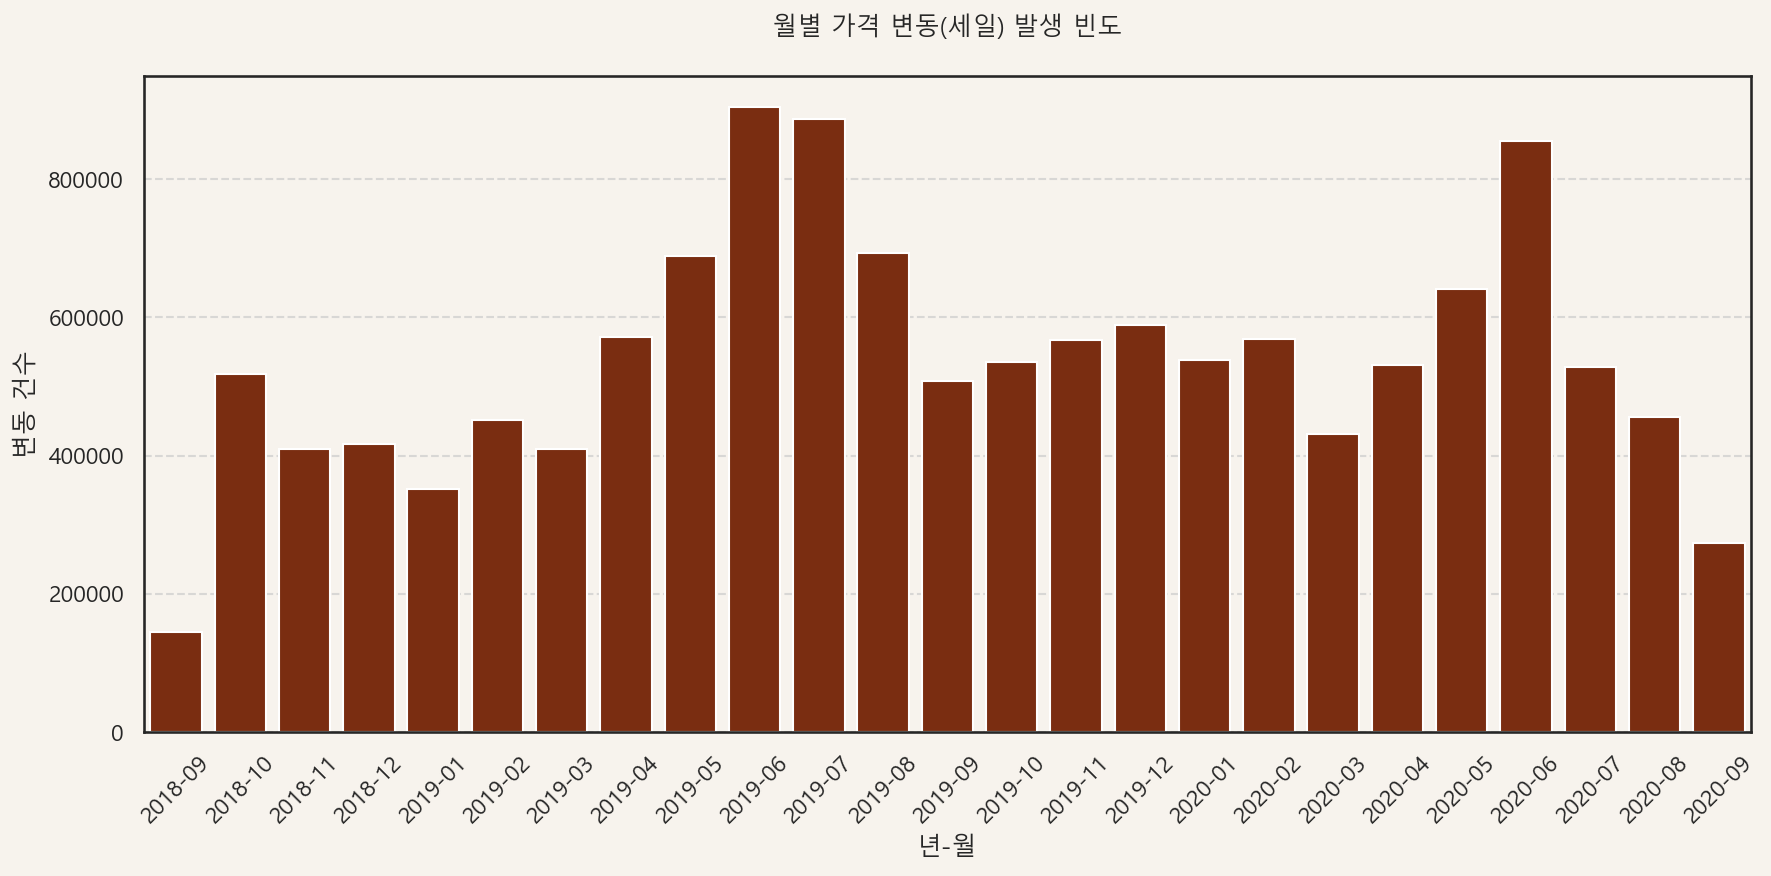

In [7]:
# 1. 날짜 데이터에서 '연-월' 추출
change_timeline['year_month'] = change_timeline['change_date'].dt.to_period('M').astype(str)

# 2. 월별 변동 건수 집계
monthly_changes = change_timeline.groupby('year_month').size().reset_index(name='count')

# 3. 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_changes, x='year_month', y='count', color=COLOR_MAIN)

plt.title('월별 가격 변동(세일) 발생 빈도', pad=20)
plt.xlabel('년-월')
plt.ylabel('변동 건수')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

- 어떤 제품이 가격변동(세일)이 많은가

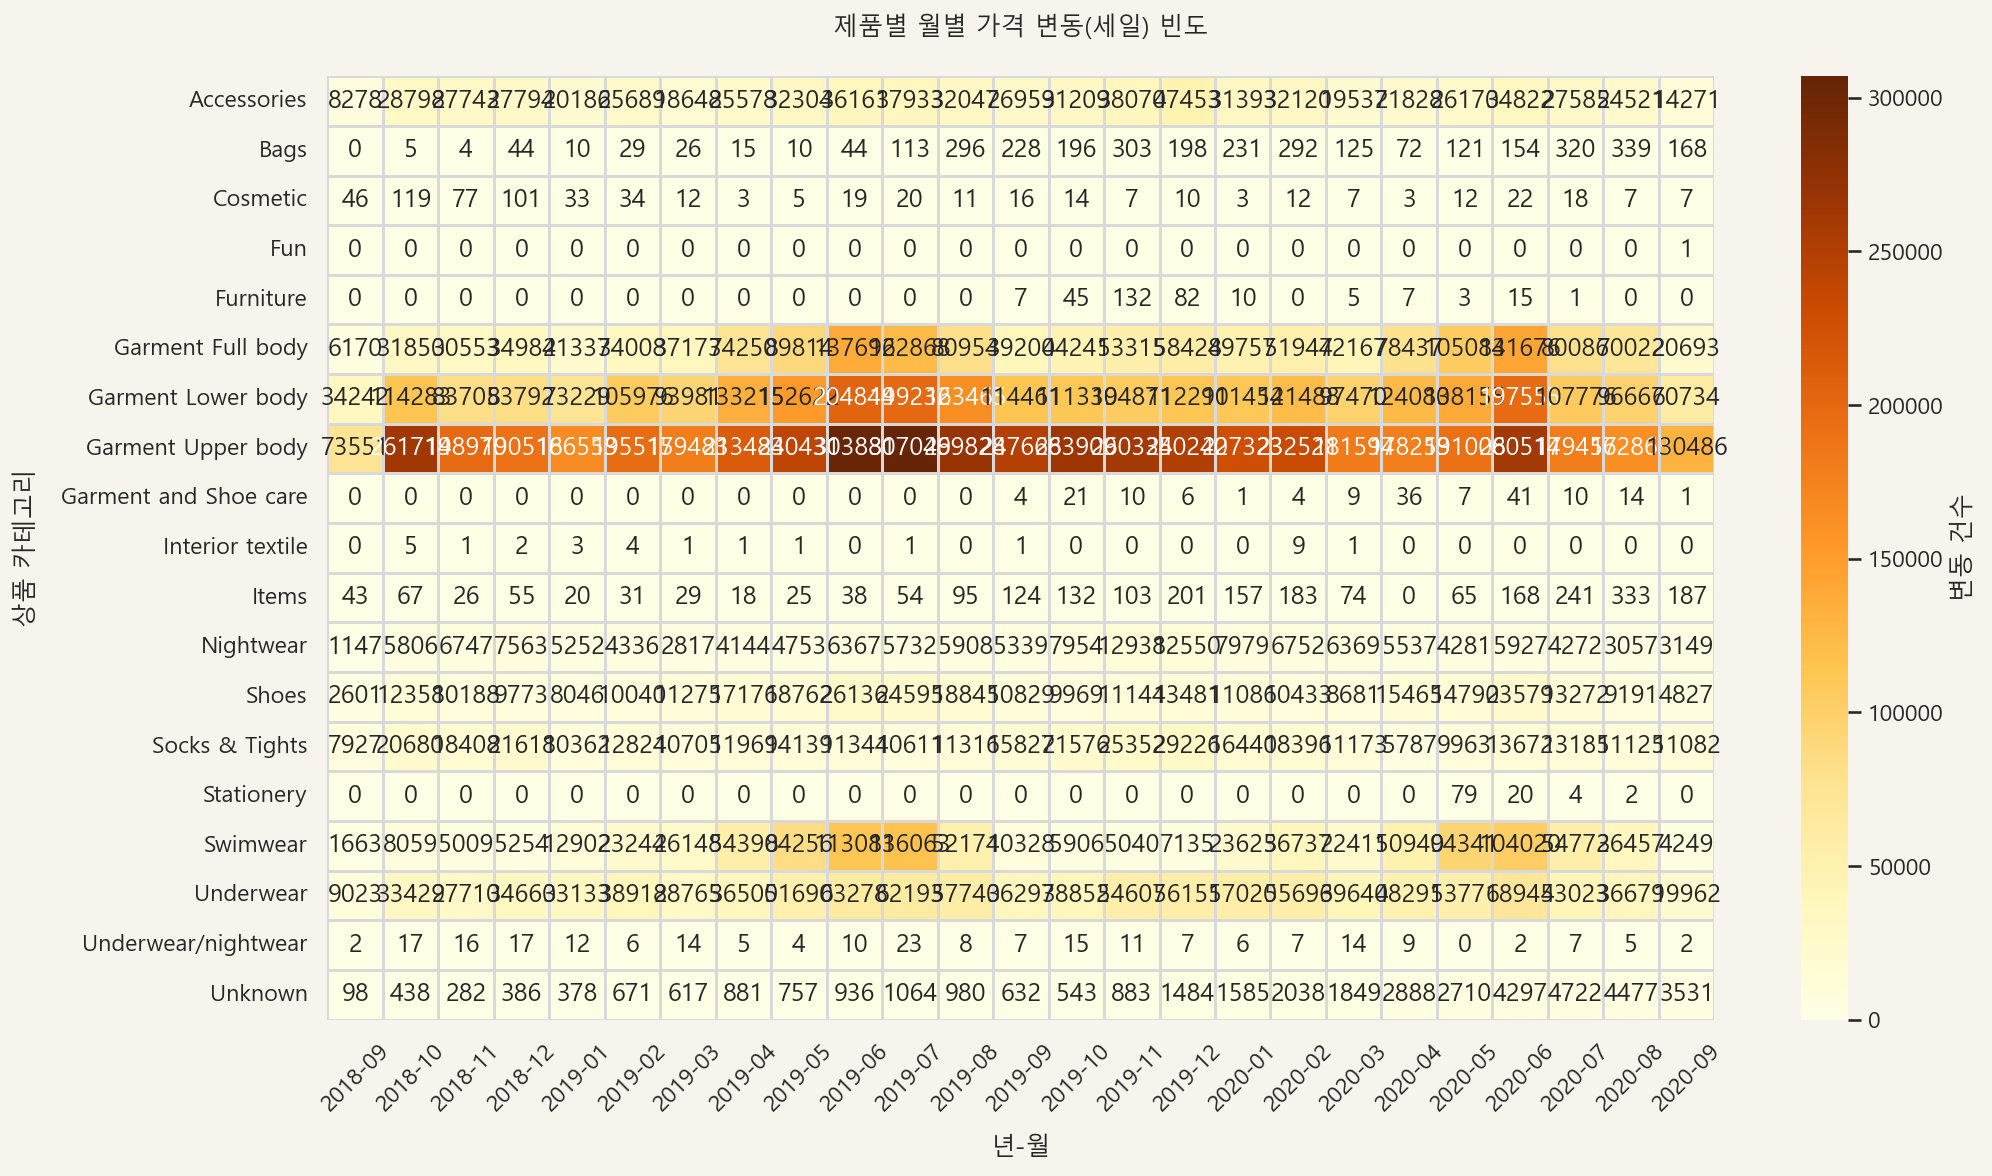

In [11]:
import seaborn as sns

# 1. '연-월' 데이터 추출 (change_timeline는 아까 만들어둔 변수입니다)
# (이미 문자열로 바꿨다면 이 줄은 생략 가능)
change_timeline['year_month'] = change_timeline['change_date'].dt.to_period('M').astype(str)

# 2. 월별, 카테고리별 변동 건수 집계
# 'product_group_name'을 기준으로 묶습니다.
category_monthly_changes = change_timeline.groupby(['product_group_name', 'year_month']).size().reset_index(name='count')

# 3. 히트맵을 그리기 위해 데이터 피벗 (Pivot)
# 행: 카테고리, 열: 월, 값: 건수
heatmap_data = category_monthly_changes.pivot(index='product_group_name', columns='year_month', values='count').fillna(0)

# 4. 시각화 (히트맵)
plt.figure(figsize=(14, 8))

# annot=True: 숫자 표시, fmt='g': 정수 포맷
# cmap: 색상 팔레트 (연한 베이지 -> 진한 갈색으로 변하는 느낌)
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlOrBr', 
            linewidths=0.5, linecolor=COLOR_NEUTRAL, cbar_kws={'label': '변동 건수'})

plt.title('제품별 월별 가격 변동(세일) 빈도', pad=20)
plt.xlabel('년-월', labelpad=10)
plt.ylabel('상품 카테고리', labelpad=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


- 어떤카테고리가 가장 가격변동(세일)을 많이하는가
인사이트:Garment Upper body(상의),Garment Upper body(상의)압도적으로 자주 세일을 합니다. 이는 이 카테고리들이 트렌드에 민감하여 재고 회전율이 빠르고, 그만큼 악성 재고가 될 확률도 높다

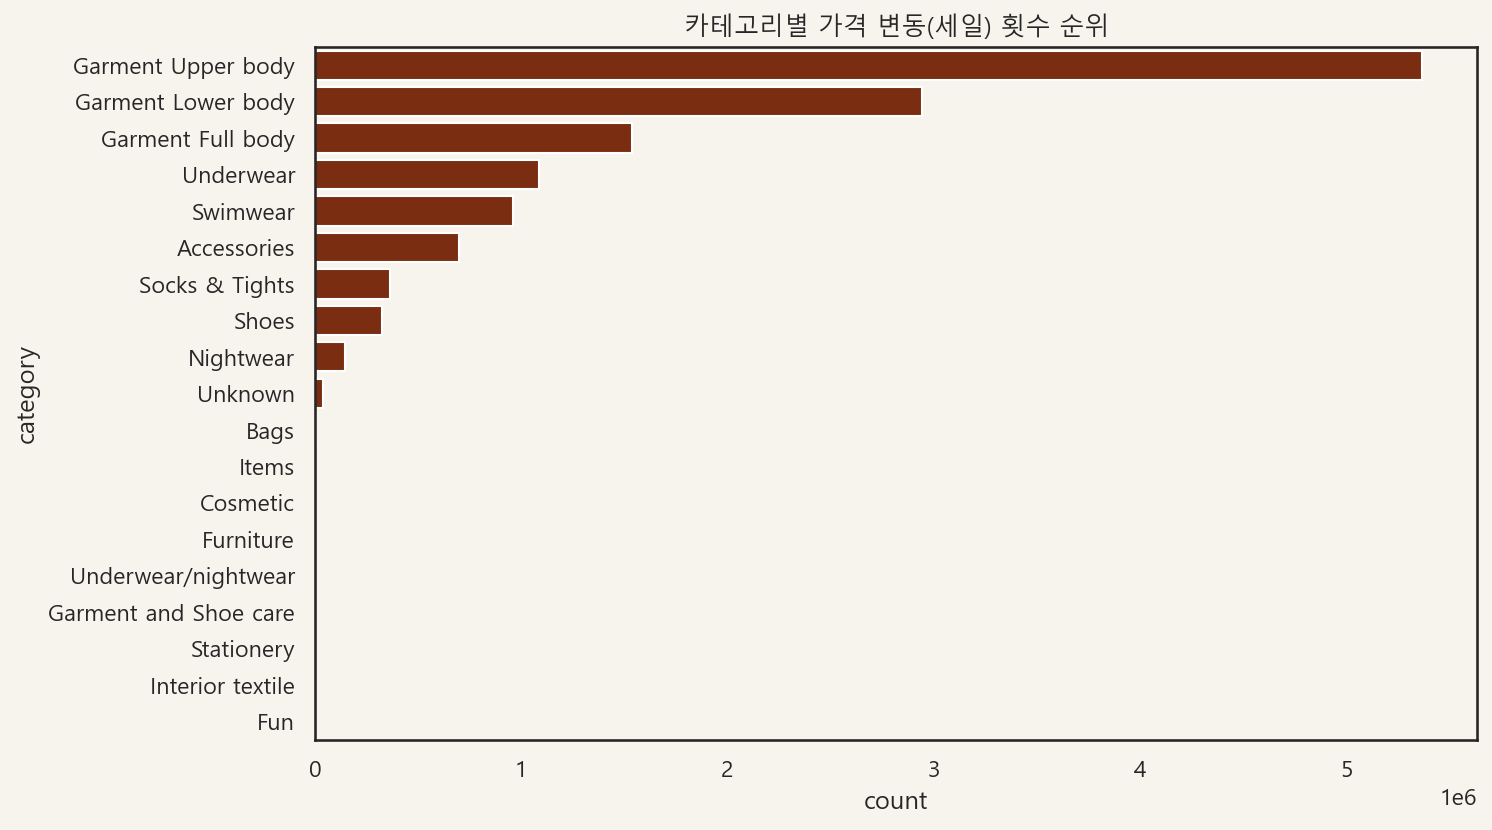

In [9]:
# 카테고리별 변동 건수 계산 및 정렬
cat_counts = change_timeline['product_group_name'].value_counts().reset_index()
cat_counts.columns = ['category', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_counts, x='count', y='category', color=COLOR_MAIN)
plt.title('카테고리별 가격 변동(세일) 횟수 순위')
plt.show()

# 할인율 분석

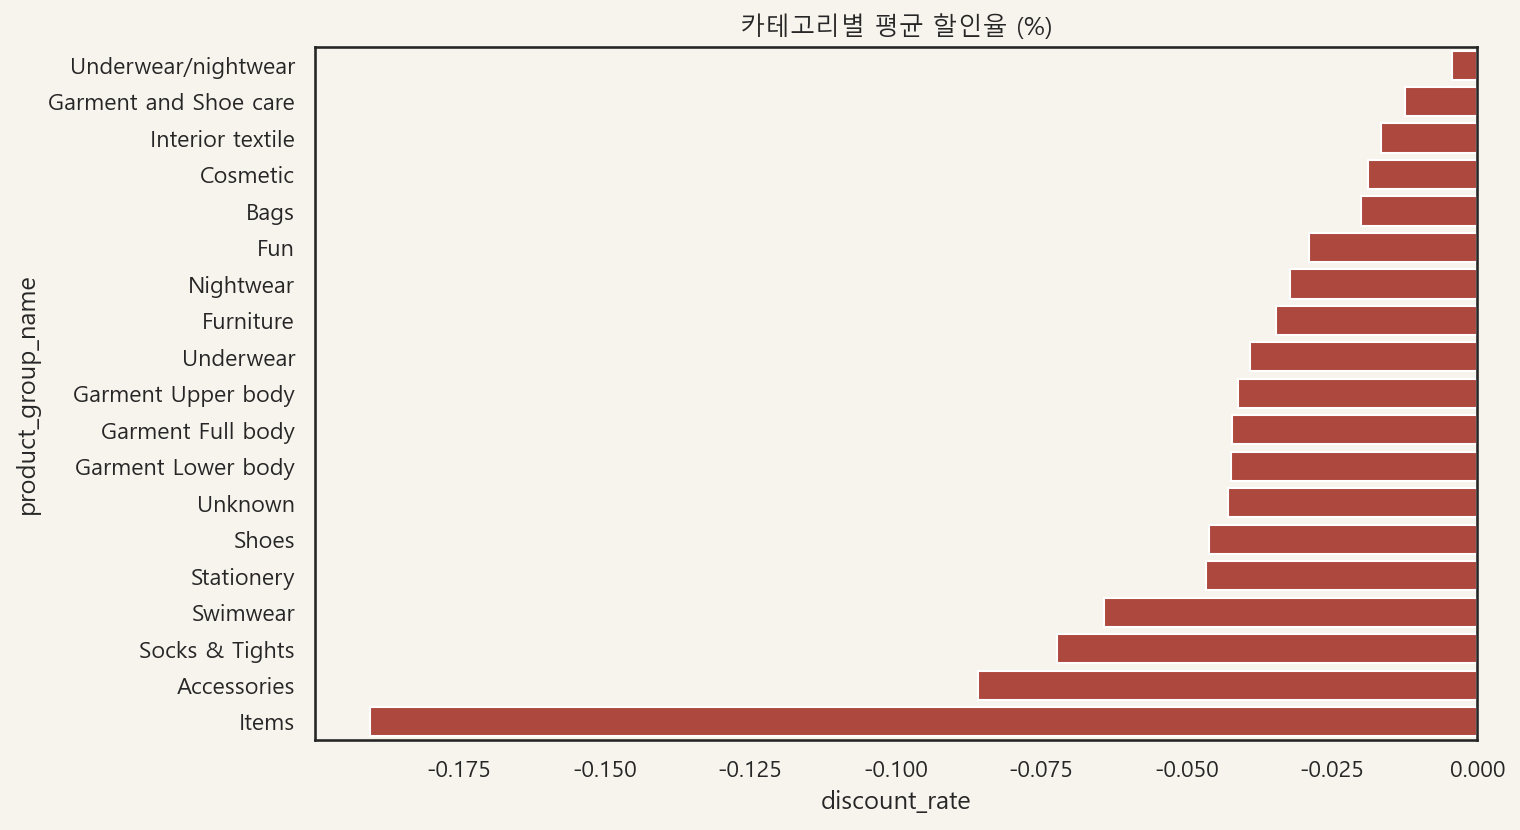

In [10]:
# 할인율 계산: (이전가격 - 새가격) / 이전가격
change_timeline['discount_rate'] = (change_timeline['prev_price'] - change_timeline['new_price']) / change_timeline['prev_price']

# 카테고리별 평균 할인율 계산
avg_discount = change_timeline.groupby('product_group_name')['discount_rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_discount, x='discount_rate', y='product_group_name', color=COLOR_ACCENT)
plt.title('카테고리별 평균 할인율 (%)')
plt.show()

In [12]:
first_seen = df.groupby('article_id')['t_dat'].min().reset_index()
first_seen.columns = ['article_id', 'first_seen']
df_cw = df.merge(first_seen, on='article_id')
df_cw['days_since_first'] = (df_cw['t_dat'] - df_cw['first_seen']).dt.days
# 출시 후 4주(28일) 이내 거래 건수
first_4w = df_cw[df_cw['days_since_first'] <= 28].groupby('article_id').size().reindex(first_seen['article_id']).fillna(0)
cold = (first_4w <= 5).sum()
warm = (first_4w > 5).sum()
cold_rev = df_cw[df_cw['article_id'].isin(first_4w[first_4w <= 5].index)].groupby('article_id')['price_eur'].sum().sum()
warm_rev = df_cw[df_cw['article_id'].isin(first_4w[first_4w > 5].index)].groupby('article_id')['price_eur'].sum().sum()
total_rev = df['price_eur'].sum()
pct_cold = cold / (cold + warm) * 100
pct_cold_rev = cold_rev / total_rev * 100
item_status = first_4w.reset_index(name='first_4w_sales')
# 위에서 계산한 first_4w는 Series 형태이므로 데이터프레임으로 변환합니다.
# 2. Cold / Warm 라벨링 (5건 기준)
item_status['status'] = item_status['first_4w_sales'].apply(lambda x: 'Cold' if x <= 5 else 'Warm')

# 3. 상품 정보(카테고리 등)와 결합해서 보기 좋게 정리
# articles 데이터프레임과 병합합니다.
art_cols = ['article_id', 'product_group_name', 'product_type_name', 'colour_group_name']
item_status = item_status.merge(articles[art_cols], on='article_id', how='left')

# 4. 결과 확인: Cold 상품만 따로 보기
cold_items_list = item_status[item_status['status'] == 'Cold']
warm_items_list = item_status[item_status['status'] == 'Warm']

print(f"Cold 상품 수: {len(cold_items_list):,}개")
print(f"Warm 상품 수: {len(warm_items_list):,}개")

# 샘플 출력
display(cold_items_list.head())

Cold 상품 수: 30,844개
Warm 상품 수: 73,556개


,article_id,first_4w_sales,status,product_group_name,product_type_name,colour_group_name
11,0112679048,2,Cold,Garment Upper body,Sweater,Grey
12,0112679052,2,Cold,Garment Upper body,Sweater,Light Blue
13,0114428026,3,Cold,Underwear,Bra,White
20,0118458034,1,Cold,Garment Lower body,Trousers,Pink
31,0126589011,2,Cold,Accessories,Hair clip,Silver


In [14]:
warm_items_list

,article_id,first_4w_sales,status,product_group_name,product_type_name,colour_group_name
0,0108775015,1462,Warm,Garment Upper body,Vest top,Black
1,0108775044,640,Warm,Garment Upper body,Vest top,White
2,0108775051,160,Warm,Garment Upper body,Vest top,Off White
3,0110065001,167,Warm,Underwear,Bra,Black
4,0110065002,71,Warm,Underwear,Bra,White
...,...,...,...,...,...,...
104395,0952267001,39,Warm,Socks & Tights,Underwear Tights,Black
104396,0952938001,9,Warm,Garment Upper body,Top,Beige
104397,0953450001,17,Warm,Socks & Tights,Socks,Black
104398,0953763001,35,Warm,Garment Upper body,Vest top,Black


- cold상품이 왜 안팔렸는가 warm과 가격비교

In [13]:
# Cold와 Warm의 평균 가격 비교
status_price = item_status.merge(df[['article_id', 'price_eur']], on='article_id')
print(status_price.groupby('status')['price_eur'].mean())

status
Cold    15.146856
Warm    16.243573
Name: price_eur, dtype: float64


- "왜 싼데 안 팔릴까?"를 확실히 증명하기 위해 카테고리별 비중을 한 번만 더 체크

In [16]:
# Cold 상품과 Warm 상품의 카테고리 구성 차이 확인
cold_cats = item_status[item_status['status'] == 'Cold']['product_group_name'].value_counts(normalize=True)
warm_cats = item_status[item_status['status'] == 'Warm']['product_group_name'].value_counts(normalize=True)

print("--- Cold 상품 카테고리 비중 ---")
print(cold_cats.head())
print("--- Warm 상품 카테고리 비중 ---")
print(warm_cats.head())

--- Cold 상품 카테고리 비중 ---
product_group_name
Garment Upper body    0.393172
Garment Lower body    0.194106
Accessories           0.117884
Garment Full body     0.116781
Shoes                 0.068571
Name: proportion, dtype: float64
--- Warm 상품 카테고리 비중 ---
product_group_name
Garment Upper body    0.409633
Garment Lower body    0.185532
Garment Full body     0.129711
Accessories           0.100182
Underwear             0.058214
Name: proportion, dtype: float64


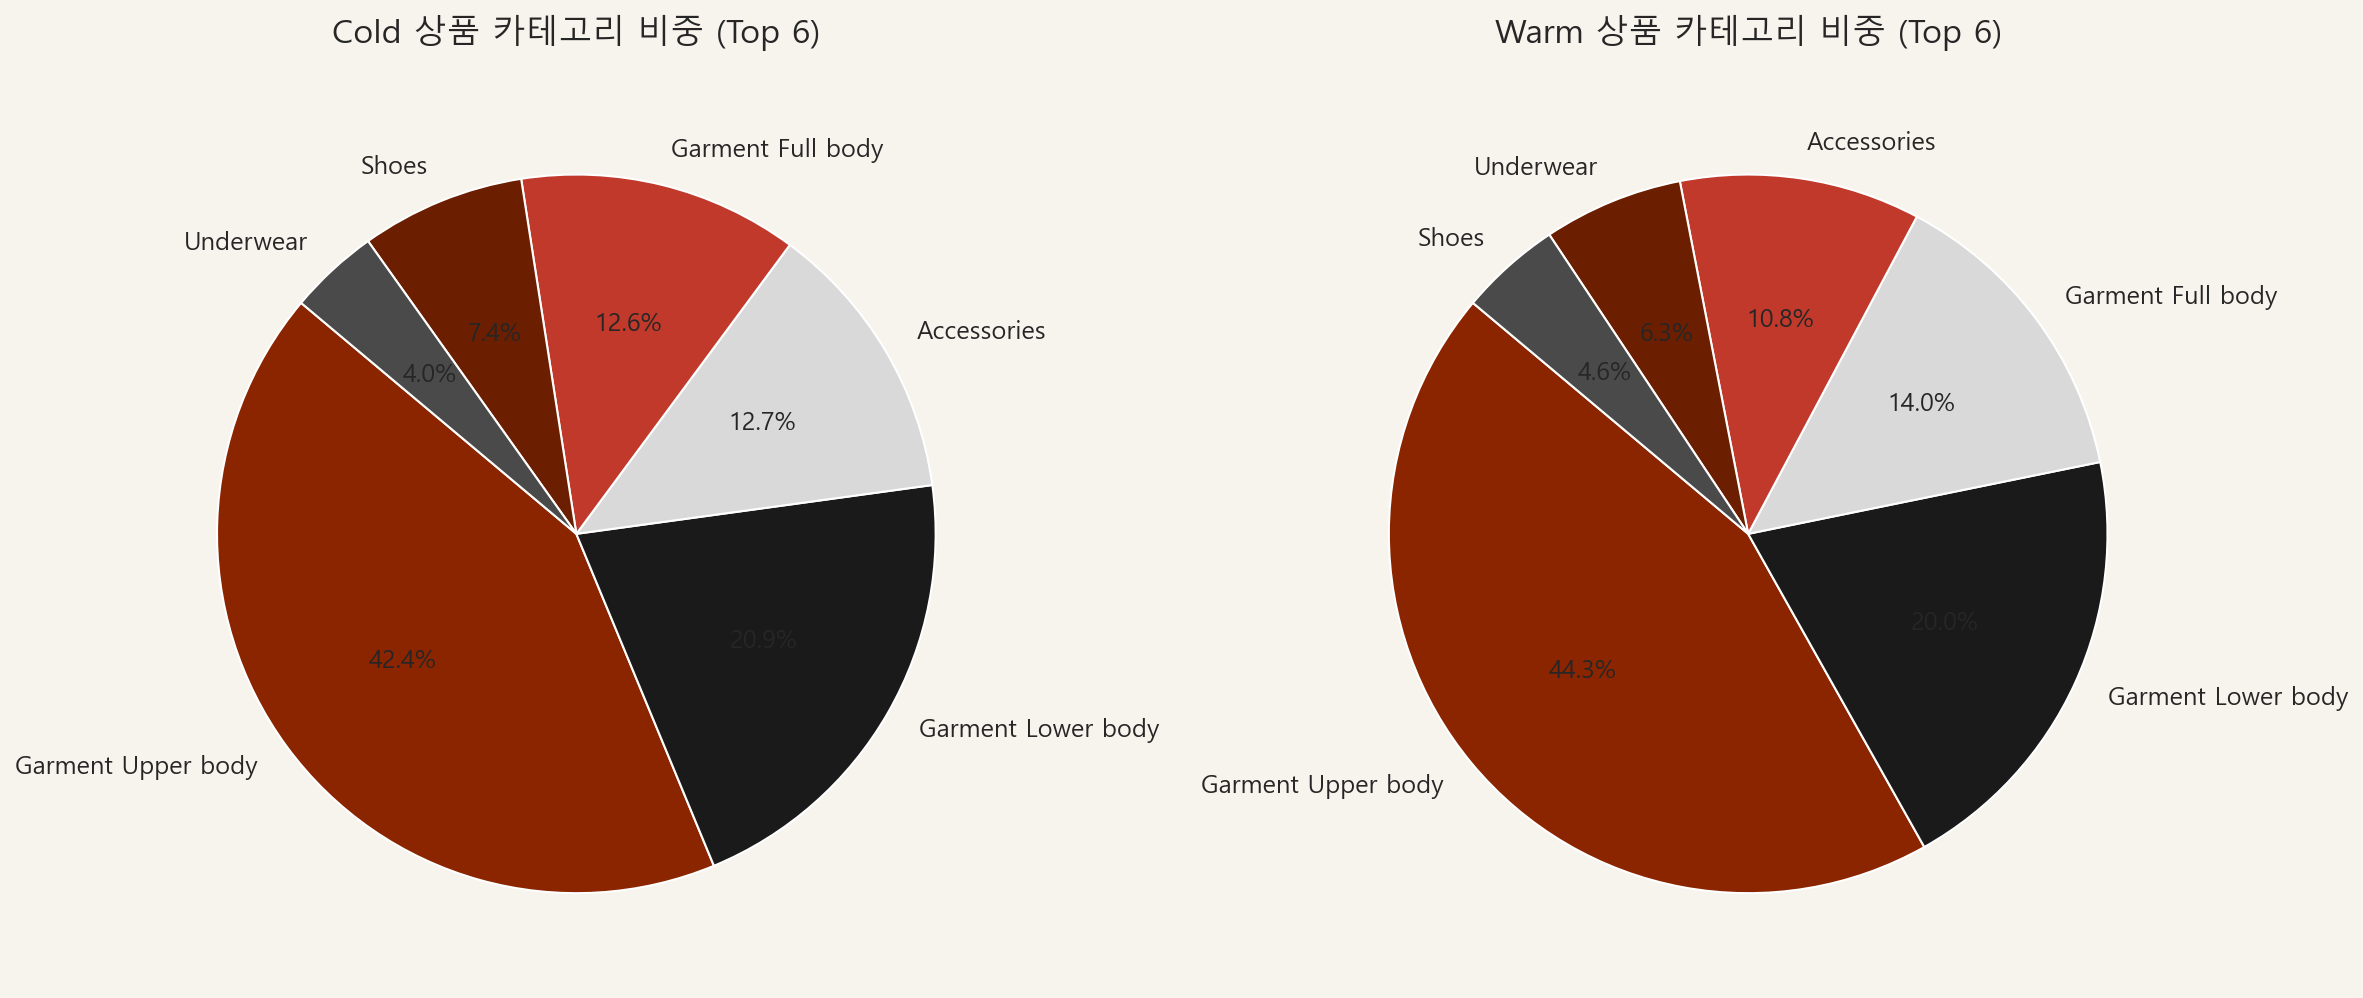

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화용 데이터 준비 (상위 5개 카테고리만 사용)
# cold_cats, warm_cats를 사용합니다.
cold_top5 = cold_cats.head(6).reset_index()
cold_top5.columns = ['category', 'ratio']

warm_top5 = warm_cats.head(6).reset_index()
warm_top5.columns = ['category', 'ratio']

# 2. 색상 팔레트 정의 
# PALETTE는 이미 정의되어 있다고 가정합니다.
pie_colors = PALETTE

# 3. 파이 차트 그리기
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Cold 상품 파이 차트 (왼쪽) ---
axes[0].pie(cold_top5['ratio'], labels=cold_top5['category'], autopct='%1.1f%%', 
            startangle=140, colors=pie_colors, textprops={'fontsize': 12})
axes[0].set_title('Cold 상품 카테고리 비중 (Top 6)', fontsize=16, pad=20)

# --- Warm 상품 파이 차트 (오른쪽) ---
axes[1].pie(warm_top5['ratio'], labels=warm_top5['category'], autopct='%1.1f%%', 
            startangle=140, colors=pie_colors, textprops={'fontsize': 12})
axes[1].set_title('Warm 상품 카테고리 비중 (Top 6)', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

- 가장 거래가 활발한 '상의'라는 동일한 체급 내에서 비교

In [20]:
# 1. 가장 비중이 큰 상의(Garment Upper body)만 필터링
upper_body = item_status[item_status['product_group_name'] == 'Garment Upper body']

# 2. Cold와 Warm 상의의 색상(colour_group_name) 비중 비교
cold_colors = upper_body[upper_body['status'] == 'Cold']['colour_group_name'].value_counts(normalize=True).head(6)
warm_colors = upper_body[upper_body['status'] == 'Warm']['colour_group_name'].value_counts(normalize=True).head(6)

print("--- Cold 상의 주요 색상 ---")
print(cold_colors)
print("--- Warm 상의 주요 색상 ---")
print(warm_colors)

--- Cold 상의 주요 색상 ---
colour_group_name
Dark Blue     0.149089
Black         0.141750
White         0.117671
Light Pink    0.062588
Grey          0.057640
Red           0.034963
Name: proportion, dtype: float64
--- Warm 상의 주요 색상 ---
colour_group_name
Black          0.196907
White          0.130231
Dark Blue      0.103050
Grey           0.050745
Light Pink     0.042647
Light Beige    0.039096
Name: proportion, dtype: float64



- 인사이트: Black과 White는 Warm 상품 비중이 압도적으로 높습니다.고객들은 기본 색상에 대해서는 가격이 조금 더 비싸더라도 확실하게 구매를 결정합니다. 즉, 안정적인 수요가 보장된 '안전 자산' 같은 상품들입니다.

- 인사이트:Dark Blue와 Red는 오히려 Cold 비중이 훨씬 높습니다. 레드처럼 강렬한 색상은 가격이 싸더라도 대중적인 선택을 받기 어렵습니다. **'취향을 심하게 타는 상품'**들이 초기에 판매되지 못하고 재고로 남은 것입니다.

- 'Light Pink'와 'Grey'의 미세한 차이: 두 색상 모두 Cold 비중이 더 높습니다. 이런 파스텔톤이나 무채색 계열도 기본 블랙/화이트에 비하면 '상대적 비인기 종목'임을 보여줍니다.

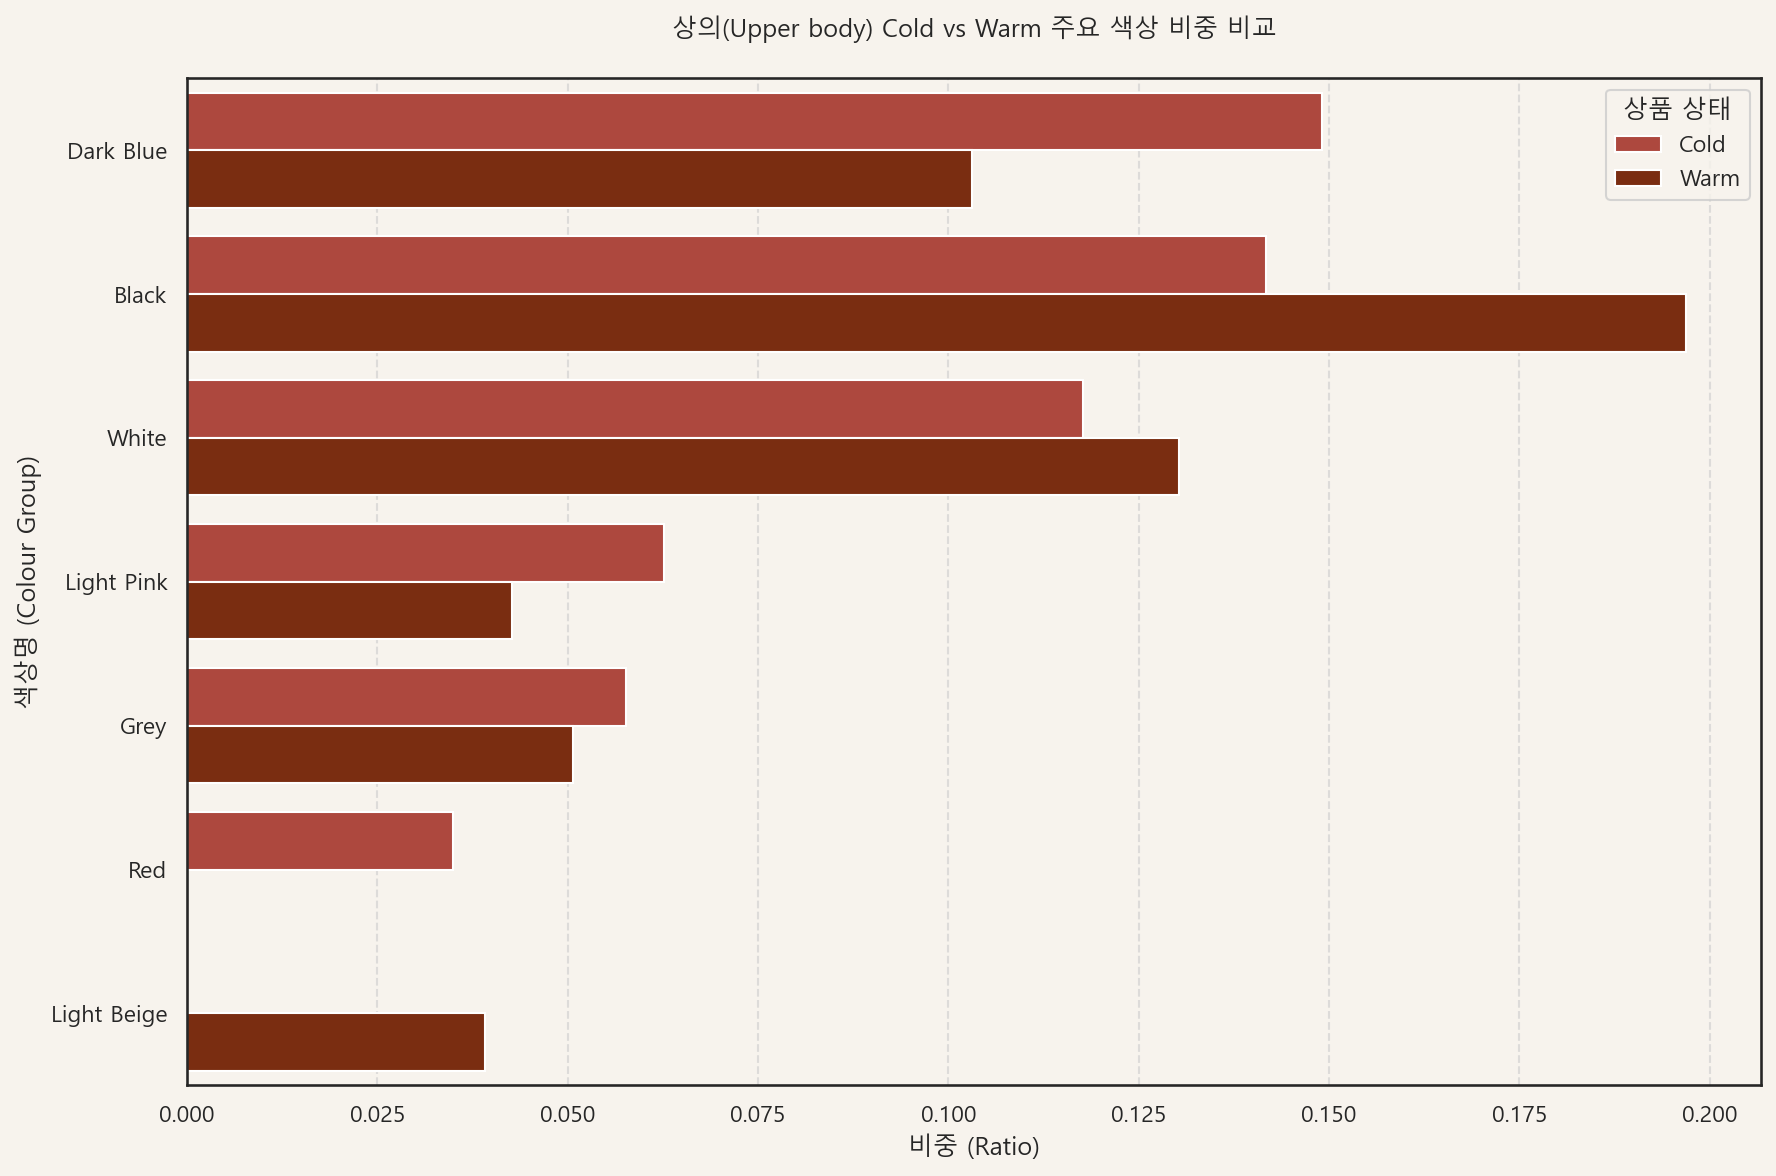

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 정리
cold_df = cold_colors.reset_index()
cold_df.columns = ['color', 'ratio']
cold_df['status'] = 'Cold'

warm_df = warm_colors.reset_index()
warm_df.columns = ['color', 'ratio']
warm_df['status'] = 'Warm'

# 두 데이터를 하나로 합침
compare_df = pd.concat([cold_df, warm_df])

# 2. 시각화
plt.figure(figsize=(12, 8))
sns.barplot(data=compare_df, x='ratio', y='color', hue='status', palette=[COLOR_ACCENT, COLOR_MAIN])

plt.title('상의(Upper body) Cold vs Warm 주요 색상 비중 비교', pad=20)
plt.xlabel('비중 (Ratio)')
plt.ylabel('색상명 (Colour Group)')
plt.legend(title='상품 상태')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
df['price_eur']

In [ ]:
p99 = df['price_eur'].quantile(0.99)
df['price_eur'] = np.clip(df['price_eur'], a_min=0.1, a_max=p99)

In [8]:
df['price_eur'].value_counts().sort_index(ascending=True)

price_eur
2.11     317994
2.12        338
2.13        895
2.14        363
2.15        698
          ...  
59.09        54
59.10        72
59.11        68
59.12        48
59.13    317885
Name: count, Length: 5654, dtype: int64

In [2]:
import pandas as pd
customers = pd.read_csv('customers.csv')
customers

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...
...,...,...,...,...,...,...,...
1371975,ffffbbf78b6eaac697a8a5dfbfd2bfa8113ee5b403e474...,NaN,NaN,ACTIVE,NONE,24.0,7aa399f7e669990daba2d92c577b52237380662f36480b...
1371976,ffffcd5046a6143d29a04fb8c424ce494a76e5cdf4fab5...,NaN,NaN,ACTIVE,NONE,21.0,3f47f1279beb72215f4de557d950e0bfa73789d24acb5e...
1371977,ffffcf35913a0bee60e8741cb2b4e78b8a98ee5ff2e6a1...,1.0,1.0,ACTIVE,Regularly,21.0,4563fc79215672cd6a863f2b4bf56b8f898f2d96ed590e...
1371978,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,1.0,ACTIVE,Regularly,18.0,8892c18e9bc3dca6aa4000cb8094fc4b51ee8db2ed14d7...
